<a href="https://colab.research.google.com/github/marianoInsa/ONE-TelecomX-2/blob/main/challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Telecom X - Parte 2: Predicción de Cancelación (Churn)

Luego del análisis exploratorio completo realizado en la Parte 1, ahora damos el siguiente paso: **construir modelos de machine learning capaces de predecir qué clientes tienen mayor probabilidad de cancelar el servicio**.

Antes de entrenar cualquier modelo, el dato crudo (aunque ya procesado en la etapa ETL anterior) necesita ser transformado al formato y escala que los algoritmos de ML requieren. Este notebook cubre esa etapa fundamental: la **preparación de los datos para el modelado**.

---
## ⚙️ Configuración del Entorno

In [1]:
# Configuración del path para importar módulos desde src/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# Importación de módulos del notebook
from src.config import setup_plot_style
from src.data_loader import load_data
from src.preprocessing import drop_non_predictive, encode_features, split_and_balance
from src.visualization import (
    plot_class_distribution,
    plot_distribution_eda,
    plot_smote_comparison,
    plot_scaling_comparison,
)

# Aplicar estilo visual
setup_plot_style()
print('✅ Entorno configurado correctamente.')

✅ Entorno configurado correctamente.


---
## 📥 Carga de Datos

Partimos del dataset limpio y transformado generado en la **Parte 1** del proyecto. Este archivo CSV contiene **7.043 clientes** con **22 variables** que ya pasaron por el pipeline ETL (normalización de JSON anidado, tratamiento de nulos, codificación binaria preliminar y variables derivadas como `cuentas_diarias`).

Al cargar este dataset, evitamos repetir todo el procesamiento previo y nos concentramos exclusivamente en las transformaciones necesarias para el modelado.

In [2]:
df = load_data()

print(f'📋 Columnas: {list(df.columns)}')
df.head()

📂 Datos cargados desde: D:\CODE\ONE-TelecomX-2\data\raw\telecom_data_processed.csv
📊 Dimensiones del dataset: 7043 filas × 22 columnas
✅ Validación: esquema OK, sin valores nulos.
📋 Columnas: ['customerID', 'Churn', 'customer_gender', 'customer_seniorcitizen', 'customer_partner', 'customer_dependents', 'customer_tenure', 'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice', 'internet_onlinesecurity', 'internet_onlinebackup', 'internet_deviceprotection', 'internet_techsupport', 'internet_streamingtv', 'internet_streamingmovies', 'account_contract', 'account_paperlessbilling', 'account_paymentmethod', 'account_charges_monthly', 'account_charges_total', 'cuentas_diarias']


,customerID,Churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


### Tipos de datos y valores nulos

Antes de continuar, verificamos el estado del dataset: tipos de datos y presencia de valores faltantes. Esto nos confirma que el trabajo de limpieza de la Parte 1 fue efectivo y podemos avanzar.

In [3]:
print('=== Tipos de datos ===')
print(df.dtypes.to_string())
print(f'\n=== Valores nulos ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else '✅ No hay valores nulos.')

=== Tipos de datos ===
customerID                       str
Churn                          int64
customer_gender                  str
customer_seniorcitizen         int64
customer_partner               int64
customer_dependents            int64
customer_tenure                int64
phone_phoneservice             int64
phone_multiplelines              str
internet_internetservice         str
internet_onlinesecurity          str
internet_onlinebackup            str
internet_deviceprotection        str
internet_techsupport             str
internet_streamingtv             str
internet_streamingmovies         str
account_contract                 str
account_paperlessbilling         str
account_paymentmethod            str
account_charges_monthly      float64
account_charges_total        float64
cuentas_diarias              float64

=== Valores nulos ===
✅ No hay valores nulos.


---
# 🛠️ Preparación de los Datos

## Paso 1: Eliminación de columnas no informativas

No todas las columnas del dataset aportan valor al proceso de predicción. Se eliminan dos columnas:

1. **`customerID`**: Identificador único del cliente — etiqueta administrativa sin relación con el churn. Puede generar patrones espurios en ciertos modelos.

2. **`cuentas_diarias`**: Variable **perfectamente redundante** — es simplemente `account_charges_monthly / 30` (correlación $r = 1.0$). Mantenerla:
   - Introduce **multicolinealidad perfecta** que perjudica a modelos lineales.
   - Infla artificialmente la importancia percibida de la dimensión económica.
   - Duplica información sin agregar señal predictiva nueva.

> **Decisión:** Se eliminan `customerID` y `cuentas_diarias` del dataset antes de cualquier procesamiento posterior.

In [4]:
df = drop_non_predictive(
    df,
    columns=["customerID", "cuentas_diarias"]
    )

✅ Columnas eliminadas: ['customerID', 'cuentas_diarias']
📊 Nuevo shape: 7043 filas × 20 columnas


---
## Paso 2: Encoding de Variables Categóricas

Los algoritmos de machine learning trabajan exclusivamente con **valores numéricos**. Sin embargo, varias columnas del dataset contienen cadenas de texto como `'Fiber optic'`, `'Month-to-month'` o `'Electronic check'`.

### Implementación con `sklearn.OneHotEncoder`

A diferencia de `pd.get_dummies()`, usamos `sklearn.preprocessing.OneHotEncoder` que permite:
- **Ajustar (fit) solo en el train set** y transformar el test set con las mismas categorías → previene data leakage.
- **Manejar categorías desconocidas** en producción (`handle_unknown='infrequent_if_exist'`).
- **Persistir el encoder** para reproducibilidad en nuevos datos.

### ¿Qué se transformará?

**A) Columnas binarias con valores `'Yes'`/`'No'` en texto → Conversión directa a 1/0**

| Columna | Detalle |
|---|---|
| `account_paperlessbilling` | Almacenada como `'Yes'`/`'No'` en el CSV, aunque debía ser 0/1 |

**B) Columnas categóricas multi-clase → One-Hot Encoding (OHE)**

| Columna | Categorías | Cols. generadas (drop_first=True) |
|---|---|---|
| `customer_gender` | Male / Female | 1 |
| `phone_multiplelines` | Yes / No / No phone service | 2 |
| `internet_internetservice` | DSL / Fiber optic / No | 2 |
| `internet_onlinesecurity` | Yes / No / No internet service | 2 |
| `internet_onlinebackup` | Yes / No / No internet service | 2 |
| `internet_deviceprotection` | Yes / No / No internet service | 2 |
| `internet_techsupport` | Yes / No / No internet service | 2 |
| `internet_streamingtv` | Yes / No / No internet service | 2 |
| `internet_streamingmovies` | Yes / No / No internet service | 2 |
| `account_contract` | Month-to-month / One year / Two year | 2 |
| `account_paymentmethod` | 4 métodos de pago | 3 |

### ¿Por qué `drop_first=True`?

Eliminamos una categoría de referencia por variable para **evitar la multicolinealidad perfecta** (la "trampa de variables dummy"), donde una columna es combinación lineal perfecta de las demás. Esto es especialmente importante para modelos como la Regresión Logística.

In [5]:
cols_antes = df.shape[1]

df_encoded, ohe_encoder = encode_features(df)

df_encoded.head()

✅ Columnas binarias de texto convertidas a 0/1: ['account_paperlessbilling']
📊 Columnas antes del encoding : 20
📊 Columnas después del encoding: 31 (+11 columnas dummy)

✅ Todas las columnas son numéricas: True


,Churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,customer_gender_Male,...,internet_techsupport_Yes,internet_streamingtv_No internet service,internet_streamingtv_Yes,internet_streamingmovies_No internet service,internet_streamingmovies_Yes,account_contract_One year,account_contract_Two year,account_paymentmethod_Credit card (automatic),account_paymentmethod_Electronic check,account_paymentmethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,0,...,1,0,1,0,0,1,0,0,0,1
1,0,0,0,0,9,1,0,59.9,542.40,1,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,4,1,1,73.9,280.85,1,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1,0,13,1,1,98.0,1237.85,1,...,0,0,1,0,1,0,0,0,1,0
4,1,1,1,0,3,1,1,83.9,267.40,0,...,1,0,1,0,0,0,0,0,0,1


In [6]:
# Verificación: listamos las nuevas columnas dummy generadas
nuevas_cols = [c for c in df_encoded.columns if c not in df.columns]
print('📋 Nuevas columnas dummy generadas:')
for col in nuevas_cols:
    print(f'   • {col}')

# Confirmamos que no quedan columnas de tipo object
obj_remaining = [c for c in df_encoded.columns if df_encoded[c].dtype == object]
print(f'\n🔍 Columnas object restantes: {obj_remaining if obj_remaining else "Ninguna ✅"}')
print(f'🔍 Tipos de datos únicos: {set(str(t) for t in df_encoded.dtypes.values)}')

📋 Nuevas columnas dummy generadas:
   • customer_gender_Male
   • phone_multiplelines_No phone service
   • phone_multiplelines_Yes
   • internet_internetservice_Fiber optic
   • internet_internetservice_No
   • internet_onlinesecurity_No internet service
   • internet_onlinesecurity_Yes
   • internet_onlinebackup_No internet service
   • internet_onlinebackup_Yes
   • internet_deviceprotection_No internet service
   • internet_deviceprotection_Yes
   • internet_techsupport_No internet service
   • internet_techsupport_Yes
   • internet_streamingtv_No internet service
   • internet_streamingtv_Yes
   • internet_streamingmovies_No internet service
   • internet_streamingmovies_Yes
   • account_contract_One year
   • account_contract_Two year
   • account_paymentmethod_Credit card (automatic)
   • account_paymentmethod_Electronic check
   • account_paymentmethod_Mailed check

🔍 Columnas object restantes: Ninguna ✅
🔍 Tipos de datos únicos: {'int64', 'float64'}


---
## Paso 2b: Distribución de Variables Continuas (EDA)

Antes de avanzar al análisis de desbalance de clases, exploramos cómo se distribuyen las **tres variables numéricas continuas** del dataset, segmentadas por la variable objetivo. Esta visualización responde preguntas fundamentales:

- ¿`customer_tenure` es normal, sesgada o bimodal?
- ¿`account_charges_monthly` tiene outliers extremos?
- ¿Existen diferencias distribucionales claras entre clientes que cancelaron y los que permanecieron?

Los histogramas con KDE superpuesta y líneas de referencia (media/mediana) permiten detectar patrones que la correlación numérica por sí sola no revela.

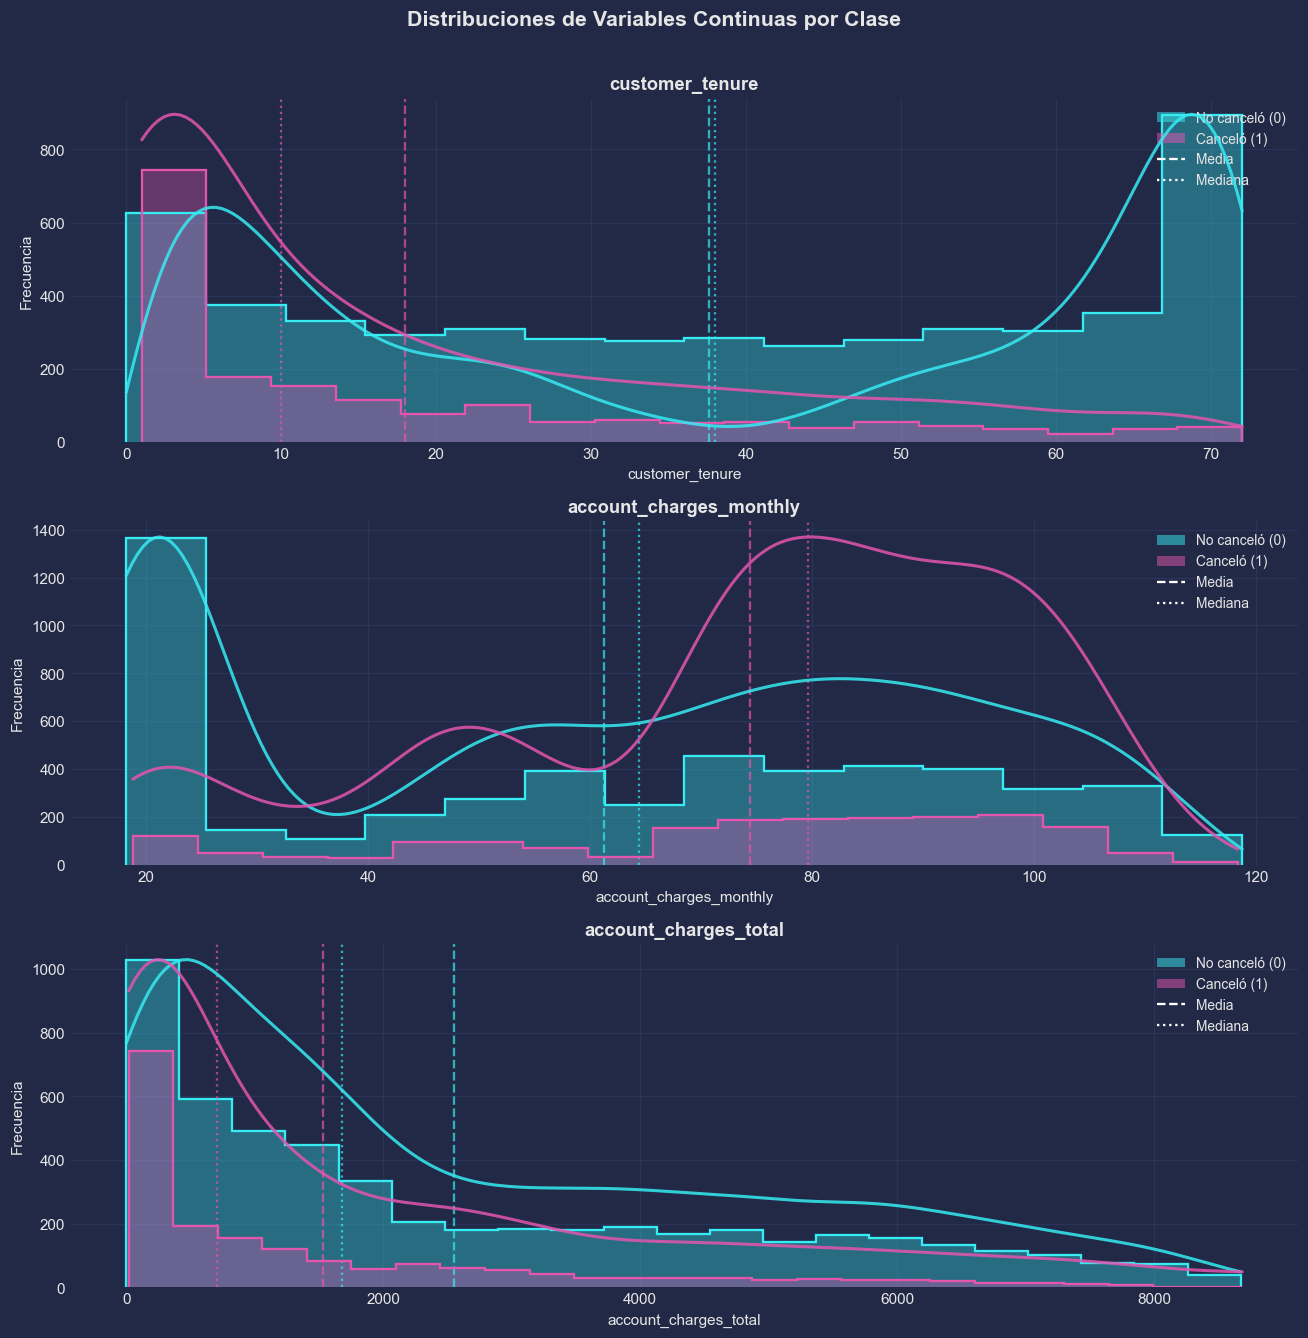

In [7]:
# Distribuciones de las 3 variables continuas, agrupadas por Churn
num_cols_eda = ['customer_tenure', 'account_charges_monthly', 'account_charges_total']
plot_distribution_eda(df_encoded, num_cols_eda)

---
## Paso 3: Análisis del Desbalance de Clases

Antes de entrenar cualquier modelo, es fundamental entender **cómo están distribuidas las clases** en la variable objetivo `Churn`. Un desbalance significativo entre clientes que cancelaron y los que permanecieron activos puede llevar a que el modelo:

- **Sesgue sus predicciones** hacia la clase mayoritaria ("todos se quedan").
- **Muestre una alta accuracy engañosa** sin detectar correctamente los casos de churn.
- **Falle en el recall de la clase minoritaria**, que es precisamente la que más nos interesa predecir.

Ya anticipamos de la Parte 1 que la tasa de churn ronda el **27%**, pero ahora lo cuantificamos formalmente sobre el dataset preparado para el modelado.

In [8]:
# Cálculo de la distribución de clases
class_counts = df_encoded['Churn'].value_counts()
class_pct    = df_encoded['Churn'].value_counts(normalize=True) * 100

print('=== Distribución de la variable objetivo (Churn) ===')
print(f'  Clase 0 | No canceló : {class_counts[0]:>5} clientes  ({class_pct[0]:.2f}%)')
print(f'  Clase 1 | Canceló    : {class_counts[1]:>5} clientes  ({class_pct[1]:.2f}%)')
ratio = class_counts[0] / class_counts[1]
print(f'\n  Ratio de desbalance  : {ratio:.2f}:1 (No Churn / Churn)')

=== Distribución de la variable objetivo (Churn) ===
  Clase 0 | No canceló :  5174 clientes  (73.46%)
  Clase 1 | Canceló    :  1869 clientes  (26.54%)

  Ratio de desbalance  : 2.77:1 (No Churn / Churn)


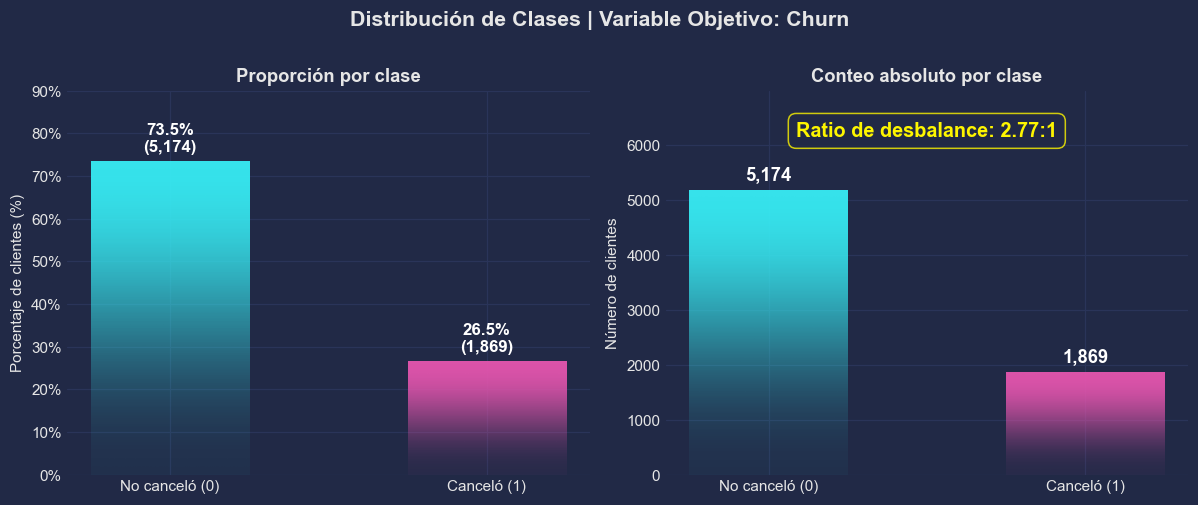

In [9]:
plot_class_distribution(class_counts, class_pct)

### 📌 Evaluación del desbalance

La proporción es aproximadamente **73.5% / 26.5%**, con un ratio de **~2.77:1** (No Churn / Churn). Si bien no es un desbalance extremo como los que se observan en detección de fraude (100:1), **sí es suficiente para afectar el desempeño de los modelos**, en especial para métricas como el **Recall de la clase 1** (detectar correctamente a los clientes que cancelan).

Para un negocio como Telecom X, un **falso negativo** (predecir que un cliente permanece cuando en realidad cancela) es mucho más costoso que un falso positivo. Por eso, **aplicaremos una técnica de balanceo** en el siguiente paso.

---
## Paso 4: División del Dataset, Escalado y Balanceo de Clases (SMOTE)

### División Train / Test

Antes de aplicar cualquier técnica de balanceo o transformación, dividimos el dataset en un conjunto de **entrenamiento (80%)** y uno de **prueba (20%)**. El parámetro `stratify=y` garantiza que ambos subconjuntos mantengan la misma proporción de clases que el dataset original.

### ¿Por qué escalar ANTES de SMOTE?

SMOTE genera ejemplos sintéticos interpolando entre vecinos cercanos utilizando **distancia euclidiana** (k-NN). Sin escalar, las features con rangos amplios (como `account_charges_total` con rango 0–8500) dominan completamente el cálculo de distancia frente a features con rangos pequeños (como `customer_seniorcitizen` con rango 0–1). Esto sesga la generación de ejemplos sintéticos.

El orden correcto del pipeline es:

```
split → scale (fit solo en train) → SMOTE (sobre datos escalados)
```

El `StandardScaler` se ajusta (fit) **exclusivamente** sobre el train set antes de SMOTE, y luego se aplica (transform) al test set. Esto:
- Evita data leakage del test al proceso de escalado.
- Garantiza que SMOTE genere vecinos representativos en un espacio de features equitativo.

### ¿Por qué SMOTE?

| Técnica | Mecanismo | Problema |
|---|---|---|
| **Undersampling aleatorio** | Elimina registros de la clase mayoritaria | Pierde ~3.300 registros con información valiosa |
| **Oversampling aleatorio** | Duplica registros de la clase minoritaria | Introduce exactamente los mismos ejemplos; genera overfitting |
| **SMOTE** ✅ | Genera ejemplos *sintéticos* interpolando vecinos de la clase minoritaria | Sin pérdida de datos; ejemplos nuevos y representativos |

### ¿Por qué aplica SMOTE *después* del split?

Si balanceamos primero, los ejemplos sintéticos generados estarían relacionados con datos del test set, **contaminando la evaluación** (data leakage). El conjunto de test debe replicar fielmente la distribución real del mundo.

In [10]:
# Separación de features y variable objetivo
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# División 80/20 + escalado + balanceo con SMOTE
# Flujo interno: split → scale (fit en train) → SMOTE
split = split_and_balance(X, y)

# Desempaquetar artefactos para uso posterior
X_train_bal = split.X_train_bal     # Escalado + balanceado (para todos los modelos)
y_train_bal = split.y_train_bal
X_test      = split.X_test          # Escalado (test real, sin modificar distribución)
y_test      = split.y_test
X_train     = split.X_train         # Original sin escalar ni balancear (referencia)
y_train     = split.y_train
scaler      = split.scaler          # Scaler ajustado para producción

=== División Train / Test ===
  Train : 5634 registros  (80.0%)
  Test  : 1409  registros  (20.0%)
  Features: 30 columnas

  Distribución en Train | Churn: 26.54%
  Distribución en Test  | Churn: 26.54%
=== Verificación del escalado (Train) ===
  Media promedio de todas las features : 0.000000  (esperado ≈ 0)
  Std  promedio de todas las features  : 1.000000  (esperado ≈ 1)

  Shape X_train_scaled : (5634, 30)
  Shape X_test_scaled  : (1409, 30)

✅ Estandarización completada.

✅ Escalado aplicado ANTES de SMOTE (distancia euclidiana corregida).

=== Distribución después de SMOTE (Train) ===
  Clase 0 | No canceló :  4139 registros (50.0%)
  Clase 1 | Canceló    :  4139 registros (50.0%)

  Ejemplos sintéticos generados: 2644 nuevos registros de churn

✅ Test set permanece intacto: 1409 registros (sin modificar)


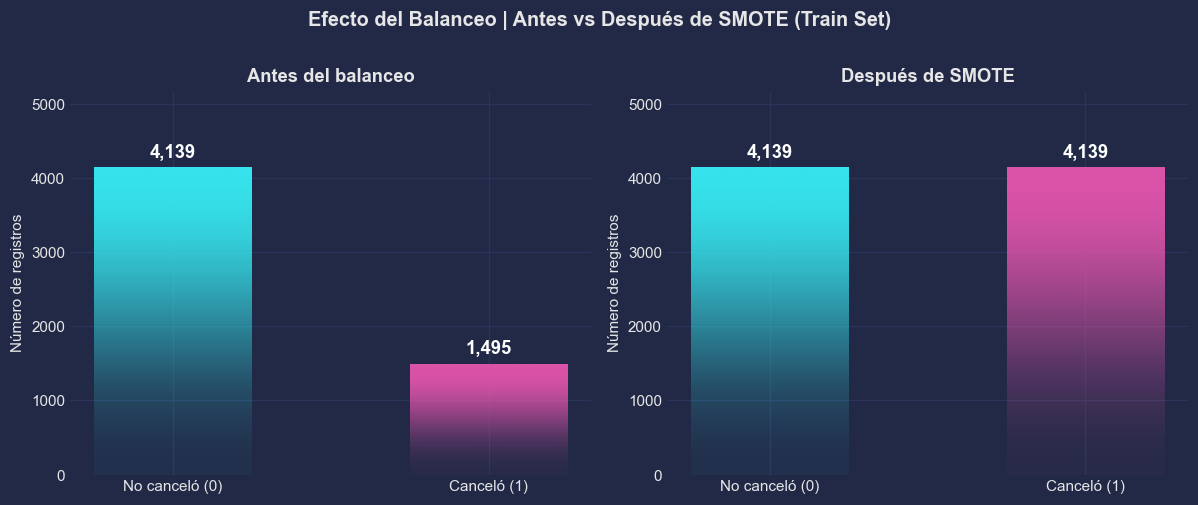

In [11]:
plot_smote_comparison(y_train, y_train_bal)

---
## Paso 5: Verificación del Escalado

El escalado se realizó automáticamente dentro del pipeline `split_and_balance()` con `StandardScaler`, **antes** de aplicar SMOTE. Esto garantiza:

1. **Distancias equitativas** para SMOTE (k-NN sobre features normalizadas).
2. **Sin data leakage**: el scaler se ajustó solo sobre `X_train`.
3. **Compatibilidad universal**: todos los artefactos (train balanceado y test) ya están escalados, listos para **cualquier familia de modelos** (árboles, logística, SVM, redes).

Visualicemos el efecto del escalado en las 3 variables numéricas continuas:

| Modelo | Sensible a escala | Beneficio del escalado previo |
|---|---|---|
| Regresión Logística | ✅ Sí | Convergencia y coeficientes correctos |
| SVM | ✅ Sí | Distancias equitativas en el kernel |
| KNN | ✅ Sí | Vecinos representativos |
| Decision Tree / Random Forest | ❌ No | Sin impacto negativo (splits sobre umbrales) |
| XGBoost | ❌ No | Sin impacto negativo |

> **Nota:** Escalar antes de SMOTE no perjudica a los árboles (son invariantes a transformaciones monótonas), pero sí beneficia a SMOTE y a los modelos sensibles a escala.

In [12]:
print('=== Verificación del escalado (ya aplicado en el pipeline) ===')
print(f'  Media promedio train: {X_train_bal.mean().mean():.6f}  (esperado ≈ 0)')
print(f'  Std  promedio train : {X_train_bal.std().mean():.6f}  (esperado ≈ 1)')
print(f'\n✅ Scaler disponible: {type(scaler).__name__}')

=== Verificación del escalado (ya aplicado en el pipeline) ===
  Media promedio train: -0.047276  (esperado ≈ 0)
  Std  promedio train : 0.955537  (esperado ≈ 1)

✅ Scaler disponible: StandardScaler


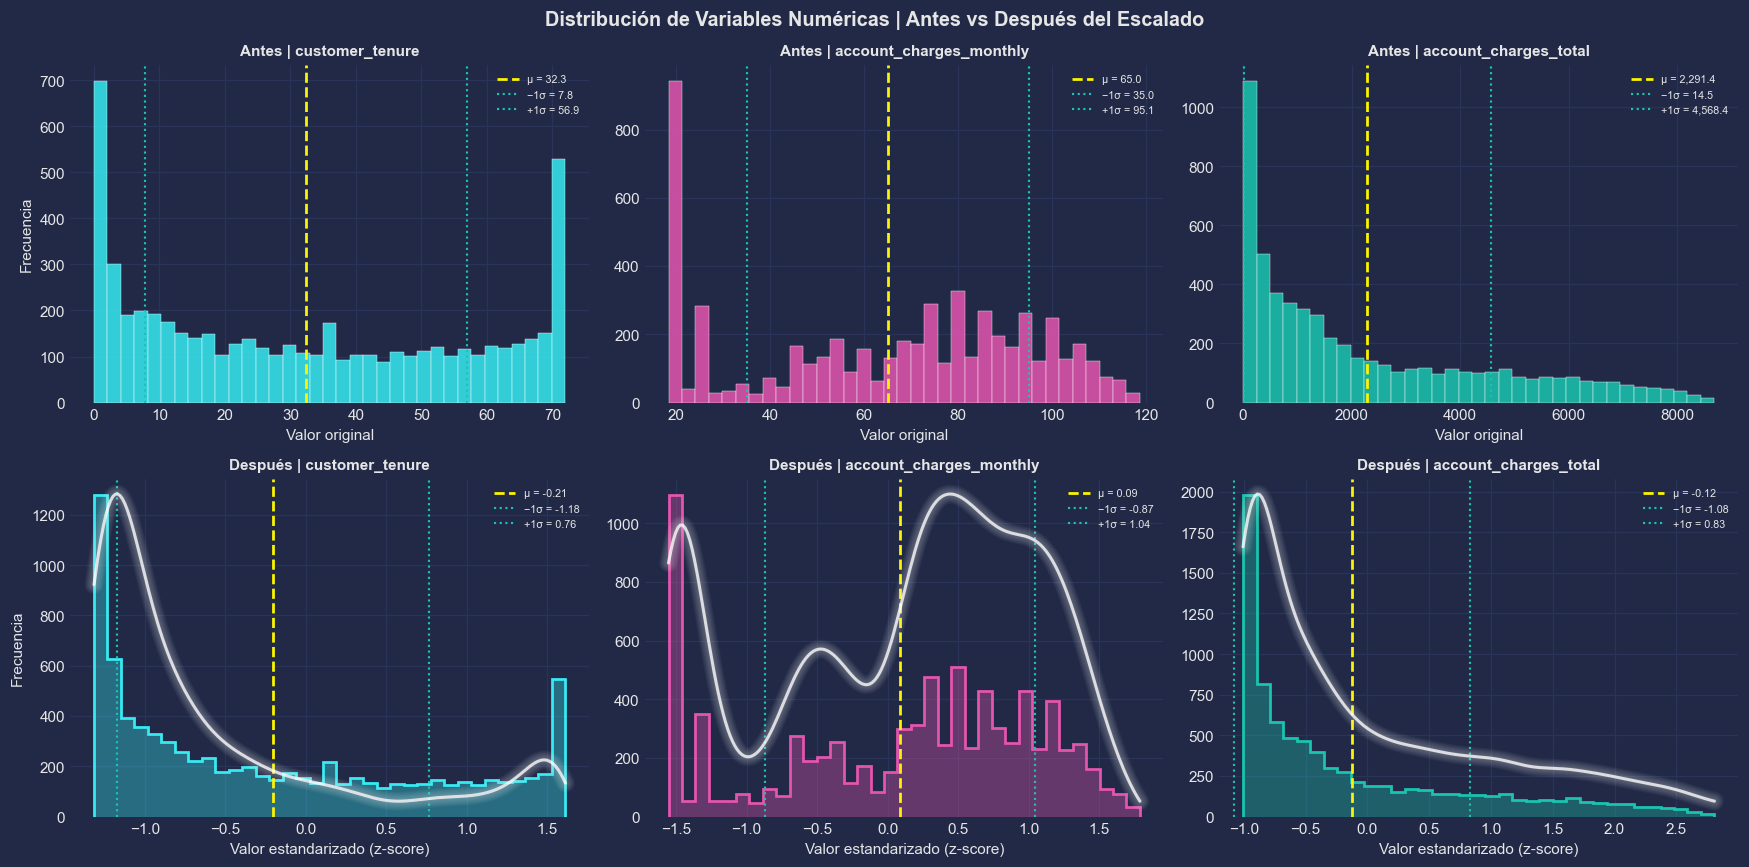

In [13]:
# X_train contiene los datos originales (sin escalar); X_train_bal los escalados + SMOTE
num_cols = ['customer_tenure', 'account_charges_monthly', 'account_charges_total']

plot_scaling_comparison(X_train, X_train_bal, num_cols)

---
## ✅ Resumen de la Preparación de Datos

Completamos todos los pasos de preparación. El dataset ha sido transformado y está listo para el modelado. A continuación, un resumen de las decisiones tomadas:

| Paso | Acción | Justificación |
|---|---|---|
| **1. Drop** | Se eliminaron `customerID` y `cuentas_diarias` | ID sin poder predictivo; `cuentas_diarias` es redundante ($r = 1.0$ con `account_charges_monthly`) |
| **2. Encoding** | `OneHotEncoder` de sklearn con `drop_first=True` + mapeo binario | Compatibilidad con ML; evita multicolinealidad; encoder reutilizable sin leakage |
| **3. Desbalance** | Ratio 2.77:1 (No Churn / Churn) detectado | Impacta recall de la clase minoritaria; requiere balanceo |
| **4. Split + Scale + SMOTE** | Pipeline integrado: split → scale (fit en train) → SMOTE | Orden correcto: escalar antes de SMOTE para distancias eucl. equitativas; sin data leakage |
| **5. Verificación** | `StandardScaler` confirmado (media≈0, std≈1) | Scaler persistido para producción |

### Artefactos generados para el modelado

| Variable | Descripción | Para usar con |
|---|---|---|
| `X_train_bal`, `y_train_bal` | Entrenamiento escalado + balanceado | **Todos los modelos** (árboles también son compatibles) |
| `X_test`, `y_test` | Test escalado (distribución real sin modificar) | Evaluación de todos los modelos |
| `X_train`, `y_train` | Train original sin escalar ni balancear | Referencia y comparación |
| `scaler` | `StandardScaler` ajustado en train | Transformar nuevos datos en producción |
| `ohe_encoder` | `OneHotEncoder` ajustado en train | Codificar nuevos datos categóricos |

El dataset codificado (`df_encoded`) se persiste en `data/processed/` para análisis de correlación en el notebook 02.

---
## 💾 Exportación del Dataset Procesado

El último paso del pipeline de preparación es **persistir el dataset transformado** en disco. Esto permite que los notebooks posteriores (correlación, modelado, evaluación) carguen directamente el dataset listo para usar, sin necesidad de re-ejecutar todo el preprocesamiento.

El archivo se guarda en `data/processed/`, siguiendo la convención del proyecto.

In [14]:
from src.config import DATA_PROCESSED_DIR

# Guardar el dataset codificado completo
output_path = DATA_PROCESSED_DIR / 'telecom_encoded.csv'
df_encoded.to_csv(output_path, index=False)

print(f'✅ Dataset exportado: {output_path}')
print(f'📊 Dimensiones: {df_encoded.shape[0]} filas × {df_encoded.shape[1]} columnas')

✅ Dataset exportado: D:\CODE\ONE-TelecomX-2\data\processed\telecom_encoded.csv
📊 Dimensiones: 7043 filas × 31 columnas
